# Predicción de atrasos en operaciones logísticas

## Objetivo
Desarrollar un modelo de Machine Learning para predecir atrasos en la atención de camiones en un centro logístico utilizando variables operacionales disponibles al momento de la programación.

## Dataset
El dataset contiene **35.250 operaciones logísticas simuladas** durante el año 2025 e incluye información sobre:

- Empresa transportista
- Patente del camión
- Tipo de operación
- Tipo de carga
- Hora programada
- Tiempos operacionales
- Minutos de atraso

## Metodología
El análisis se desarrolla en las siguientes etapas:

1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Entrenamiento de distintos modelos de Machine Learning
4. Evaluación comparativa de desempeño
5. Interpretabilidad del modelo mediante SHAP

In [1]:
#Imports
import os
import warnings

#Manipulación de datos
import numpy as np
import pandas as pd

#Vidualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

#Modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import recall_score, precision_score
from xgboost import XGBRegressor

#Interpretabilidad
import shap




RANDOM_STATE = 2026
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

## Funciones auxiliares:

In [2]:
def hhmmss_to_minutes(s: str) -> int:
    "HH:MM:SS -> minutos del día"
    h, m, _ = s.split(":")
    return int(h) * 60 + int(m)

def minutes_to_hhmmss_day(m: int) -> str:
    "minutos del día -> HH:MM:SS (ajustado a 24h)"
    m = int(m) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

def minutos_a_hhmmss(mins: float) -> str:
    "minutos -> HH:MM:SS (puede ser negativo)"
    sign = "-" if mins < 0 else ""
    mins = abs(int(round(mins)))
    h = mins // 60
    m = mins % 60
    return f"{sign}{h:02d}:{m:02d}:00"

In [3]:
# Cargar el dataset
dataset = pd.read_csv("../data/raw/logistics_24h_hhmmss.csv")
dataset.head()

,fecha,semana,empresa,patente,tipo_operacion,tipo_carga,hora_programada,hora_ingreso_real,hora_inicio_operacion,hora_fin_operacion,minutos_atraso
0,2025-04-18,16,Nivalis CargoWorks,TRK-014,Despacho,Carga Suelta,08:40:00,08:41:00,08:53:00,09:31:00,1.17
1,2025-09-20,38,Altacima Coldhaul,TRK-021,Despacho,Pallet,16:23:00,16:47:00,17:02:00,17:50:00,23.84
2,2025-04-24,17,VentiscaLine Transport,TRK-037,Recepcion,Pallet,18:45:00,19:25:00,19:46:00,20:56:00,39.87
3,2025-01-18,3,CumbreKargo 24,TRK-023,Despacho,Pallet,04:47:00,05:30:00,05:35:00,06:08:00,42.99
4,2025-06-25,26,Nivalis CargoWorks,TRK-007,Despacho,Carga Suelta,06:12:00,06:21:00,06:27:00,07:24:00,8.76


## Calidad de los datos

In [4]:
# Convertir variables a tipos adecuados

# Fecha a datetime
dataset["fecha"] = pd.to_datetime(dataset["fecha"])

# Variables categóricas
categorical_cols = ["empresa","patente","tipo_operacion","tipo_carga"]

for col in categorical_cols:
    dataset[col] = dataset[col].astype("category")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35250 entries, 0 to 35249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   fecha                  35250 non-null  datetime64[ns]
 1   semana                 35250 non-null  int64         
 2   empresa                35250 non-null  category      
 3   patente                35250 non-null  category      
 4   tipo_operacion         35250 non-null  category      
 5   tipo_carga             35250 non-null  category      
 6   hora_programada        35250 non-null  object        
 7   hora_ingreso_real      35250 non-null  object        
 8   hora_inicio_operacion  35250 non-null  object        
 9   hora_fin_operacion     35250 non-null  object        
 10  minutos_atraso         35250 non-null  float64       
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 2.0+ MB


In [5]:
pd.DataFrame({"Variable": dataset.columns,"Tipo": dataset.dtypes})

,Variable,Tipo
fecha,fecha,datetime64[ns]
semana,semana,int64
empresa,empresa,category
patente,patente,category
tipo_operacion,tipo_operacion,category
tipo_carga,tipo_carga,category
hora_programada,hora_programada,object
hora_ingreso_real,hora_ingreso_real,object
hora_inicio_operacion,hora_inicio_operacion,object
hora_fin_operacion,hora_fin_operacion,object


In [6]:
#Dataset overview
print("Shape:", dataset.shape)
display(dataset.describe(include="all"))

print("\nNulos:")
display(dataset.isnull().sum())

print("\nDuplicados:", dataset.duplicated().sum())
#Al ser datos sinteticos no deberia haber nulos ni duplicados

Shape: (35250, 11)


,fecha,semana,empresa,patente,tipo_operacion,tipo_carga,hora_programada,hora_ingreso_real,hora_inicio_operacion,hora_fin_operacion,minutos_atraso
count,35250,35250.000000,35250,35250,35250,35250,35250,35250,35250,35250,35250.000000
unique,NaN,NaN,15,80,2,2,1440,1440,1440,1440,NaN
top,NaN,NaN,Nivalis CargoWorks,TRK-045,Despacho,Pallet,18:29:00,21:59:00,22:36:00,23:16:00,NaN
freq,NaN,NaN,3656,480,19438,24635,53,52,51,51,NaN
mean,2025-06-29 23:11:42.842553088,26.563404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.689004
min,2025-01-01 00:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-39.450000
25%,2025-04-01 00:00:00,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.942500
50%,2025-06-30 00:00:00,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.100000
75%,2025-09-28 00:00:00,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.827500
max,2025-12-28 00:00:00,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134.500000



Nulos:


fecha                    0
semana                   0
empresa                  0
patente                  0
tipo_operacion           0
tipo_carga               0
hora_programada          0
hora_ingreso_real        0
hora_inicio_operacion    0
hora_fin_operacion       0
minutos_atraso           0
dtype: int64


Duplicados: 0


# EDA

## Distribución de minutos de atraso
La distribución de minutos de atraso presenta una forma aproximadamente normal con ligera asimetría positiva.

La mayoría de las operaciones se concentran entre 0 y 50 minutos de atraso, con un promedio cercano a los 26 minutos.

Se observan eventos extremos superiores a 75 minutos, los cuales representan riesgos operacionales significativos.

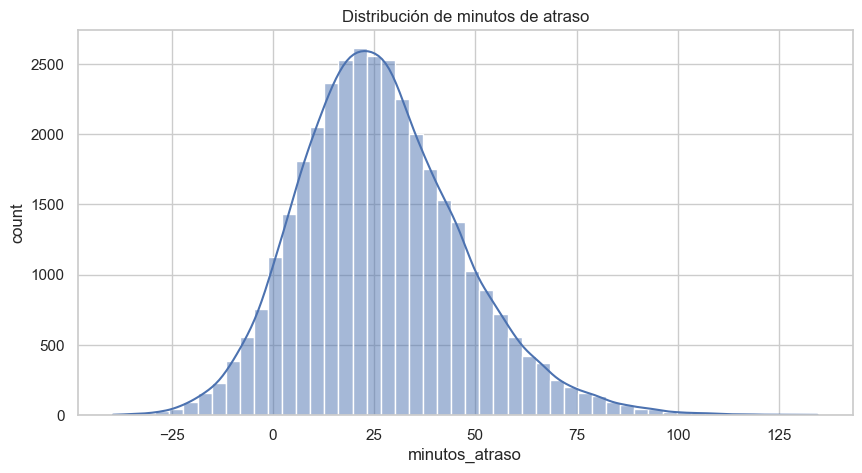

Media: 26.69
Desviación estándar: 20.08


In [7]:
#Distribución de minutos de atraso
plt.figure(figsize=(10,5))
sns.histplot(dataset["minutos_atraso"], bins=50, kde=True)
plt.title("Distribución de minutos de atraso")
plt.xlabel("minutos_atraso")
plt.ylabel("count")
plt.show()
print("Media:", dataset["minutos_atraso"].mean().round(2))
print("Desviación estándar:", dataset["minutos_atraso"].std().round(2))

In [8]:
# copiar dataset para EDA
dataset_eda=dataset.copy()
# % de llegadas tarde (Global)
dataset_eda["llego_tarde"] = dataset_eda["minutos_atraso"] > 0
tasa_global = dataset_eda["llego_tarde"].mean() * 100
print(f"Tasa global de llegadas tarde: {tasa_global:.2f}%")

Tasa global de llegadas tarde: 92.55%


## Empresas con Mayor Impacto Operacional

No todas las empresas afectan de la misma manera la operación logística.

Para identificar cuáles generan mayor problema, se construyó un indicador llamado **Impacto Operacional**, que combina dos factores clave:

- **Tasa de incumplimiento**: porcentaje de operaciones que llegan tarde.
- **Atraso promedio cuando se atrasan**: cantidad promedio de minutos de atrasos considerando solo las operaciones tardías.

El indicador se calcula de la siguiente forma:

Impacto = Tasa de incumplimiento × Atraso promedio (operaciones tardías)

Donde:

Tasa de incumplimiento = Operaciones tardías / Total de operaciones

Este cálculo permite combinar:

- La **frecuencia del problema** (qué tan seguido ocurre)
- La **gravedad del problema** (qué tan grande es cuando ocurre)

De esta manera, no solo se observa quién tiene más atrasos, sino quién genera mayor efecto total en la operación.

Por ejemplo, una empresa puede atrasarse pocas veces pero con atrasos muy largos, mientras otra puede atrasarse muchas veces pero solo algunos minutos.  
El indicador equilibra ambos factores y ayuda a priorizar aquellas empresas que realmente representan mayor riesgo operativo.

En términos prácticos, este análisis permite enfocar acciones correctivas donde el beneficio potencial es mayor.

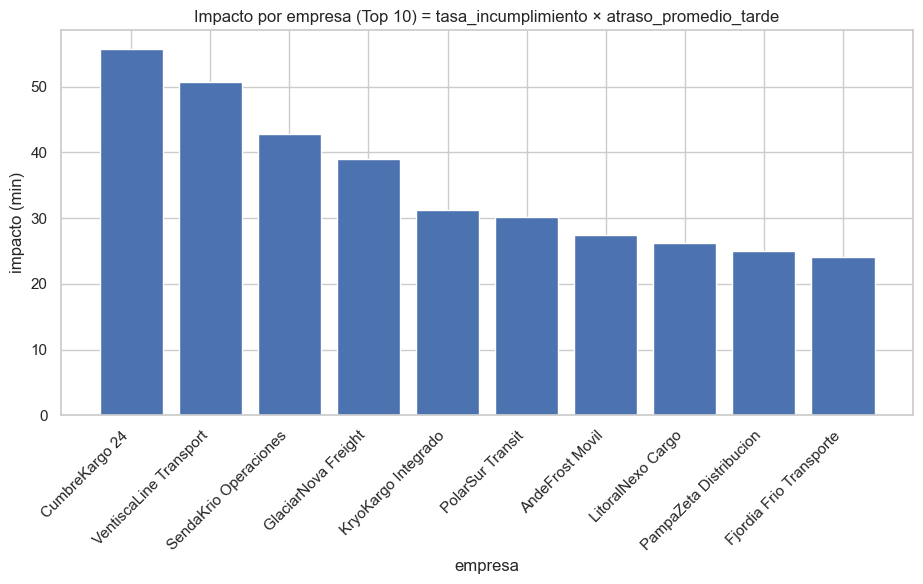

,total_ops,tasa_inc,atraso_prom_tarde,impacto
empresa,,,,
CumbreKargo 24,1036,1.00,56.01,55.79
VentiscaLine Transport,1814,1.00,50.89,50.75
SendaKrio Operaciones,2094,0.99,43.09,42.80
GlaciarNova Freight,2759,0.99,39.38,39.02
KryoKargo Integrado,2497,0.97,32.21,31.18
PolarSur Transit,2065,0.97,31.25,30.25
AndeFrost Movil,2439,0.96,28.46,27.38
LitoralNexo Cargo,2165,0.97,27.05,26.18
PampaZeta Distribucion,2154,0.96,26.07,25.04


In [10]:
#Impacto por empresa = tasa_incumplimiento × atraso_promedio_tarde
def mean_if_tarde(s):
    s = s[s > 0]
    return float(s.mean()) if len(s) else 0.0

perf = dataset_eda.groupby("empresa", observed=False).agg(
    total_ops=("minutos_atraso","size"),
    tasa_inc=("llego_tarde","mean"),
    atraso_prom_tarde=("minutos_atraso", mean_if_tarde),
)
perf["impacto"] = perf["tasa_inc"] * perf["atraso_prom_tarde"]
top_impacto = perf.sort_values("impacto", ascending=False).head(10)




plt.figure(figsize=(11,5))
plt.bar(top_impacto.index, top_impacto["impacto"].values)
plt.title("Impacto por empresa (Top 10) = tasa_incumplimiento × atraso_promedio_tarde")
plt.xlabel("empresa")
plt.ylabel("impacto (min)")
plt.xticks(rotation=45, ha="right")
plt.show()

top_impacto.round(2)    

## Heatmap de atraso promedio por empresa

El heatmap muestra cómo varía el atraso promedio según la empresa y la hora programada.

Se observa un patrón relativamente uniforme entre empresas, con incrementos graduales del atraso a lo largo del día. En particular, las horas de la tarde y noche tienden a concentrar un mayor nivel de atraso, lo que podría asociarse a una acumulación operativa o a una mayor carga logística.

Aunque las diferencias entre empresas existen, el comportamiento general sugiere que el contexto horario tiene un rol relevante en la variación de los atrasos.

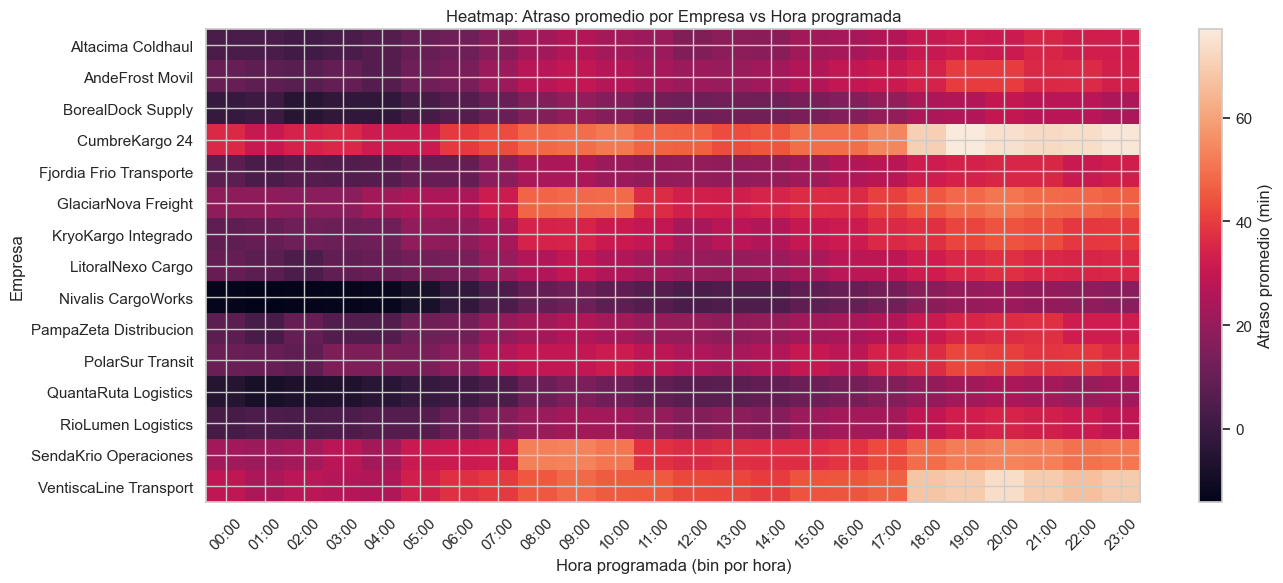

In [11]:
# Análisis de carga operacional (número de camiones) y atraso promedio por hora
# Del auxiliar: HH:MM:SS -> minuto del día
def hhmmss_to_min(s: str) -> int:
    h, m, _ = s.split(":")
    return int(h)*60 + int(m)

dataset_eda["hora_programada_min"] = dataset_eda["hora_programada"].apply(hhmmss_to_min)
dataset_eda["hora_bin"] = (dataset_eda["hora_programada_min"] // 60)  #bins por hora (0 a 23)

# pivot: filas empresa, columnas hora, valores atraso promedio
pivot = dataset_eda.pivot_table(
    index="empresa",
    columns="hora_bin",
    values="minutos_atraso",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(14,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Atraso promedio (min)")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.title("Heatmap: Atraso promedio por Empresa vs Hora programada")
plt.xlabel("Hora programada (bin por hora)")
plt.ylabel("Empresa")
plt.tight_layout()
plt.show()

## Heatmap de congestión por hora y día de la semana

Se observa un aumento progresivo de los atrasos a medida que avanza la jornada, con niveles más bajos durante la madrugada y primeras horas de la mañana. Los mayores niveles de atraso se concentran en la tarde y noche, especialmente hacia el final de la semana.

Este patrón sugiere una posible acumulación de carga operacional a lo largo del día y mayor presión logística en ciertos días, particularmente los viernes.

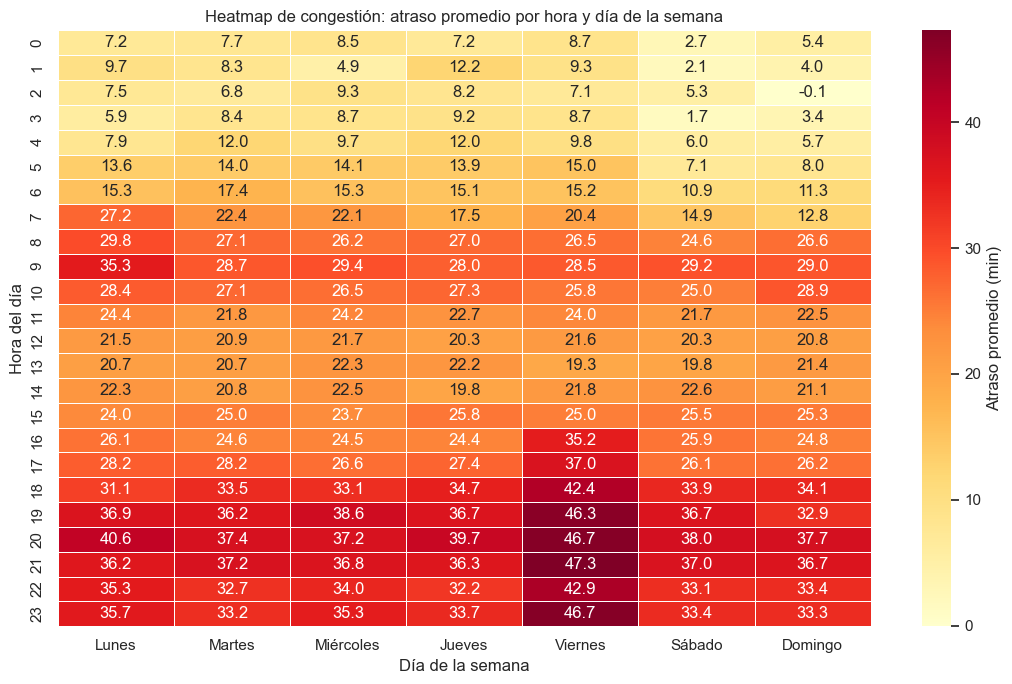

In [12]:
# Análisis de congestión: atraso promedio por hora y día de la semana

# Hora en formato entero
dataset_eda["hora"] = dataset_eda["hora_programada_min"] // 60

mapa_dias = {0: "Lunes",1: "Martes", 2: "Miércoles", 3: "Jueves",4: "Viernes",5: "Sábado",
             6: "Domingo"}
dataset_eda["dia_semana"] = dataset_eda["fecha"].dt.dayofweek.map(mapa_dias)

# Orden de días
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# Matriz hora x día
heatmap_data = (
    dataset_eda.groupby(["hora", "dia_semana"])["minutos_atraso"]
    .mean()
    .reset_index())

heatmap_pivot = heatmap_data.pivot(
    index="hora",
    columns="dia_semana",
    values="minutos_atraso")

# Asegurar orden correcto
heatmap_pivot = heatmap_pivot.reindex(columns=orden_dias)

# Asegurar horas 0-23 aunque alguna no exista
heatmap_pivot = heatmap_pivot.reindex(range(24))

# Gráfico
plt.figure(figsize=(11, 7))

sns.heatmap(
    heatmap_pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Atraso promedio (min)"})

plt.title("Heatmap de congestión: atraso promedio por hora y día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Hora del día")

plt.tight_layout()
plt.savefig("outputs/figures/heatmap_congestion_hora_dia.png", dpi=150, bbox_inches="tight")
plt.show()

## Carga operacional y atraso promedio por hora
El gráfico compara la carga operacional promedio (camiones en operación por hora) con el atraso promedio.

Las barras representan el número promedio de camiones que están siendo atendidos en la instalación según la hora de inicio de operación, mientras que la línea roja muestra el atraso promedio asociado a esas operaciones.

Se observa que tanto la carga operacional como los minutos de atraso tienden a aumentar hacia las últimas horas del día, alcanzando sus niveles más altos en la noche. Además, el atraso se mantiene elevado alrededor de la medianoche, lo que sugiere una posible acumulación de operaciones pendientes que se arrastran desde la jornada anterior.

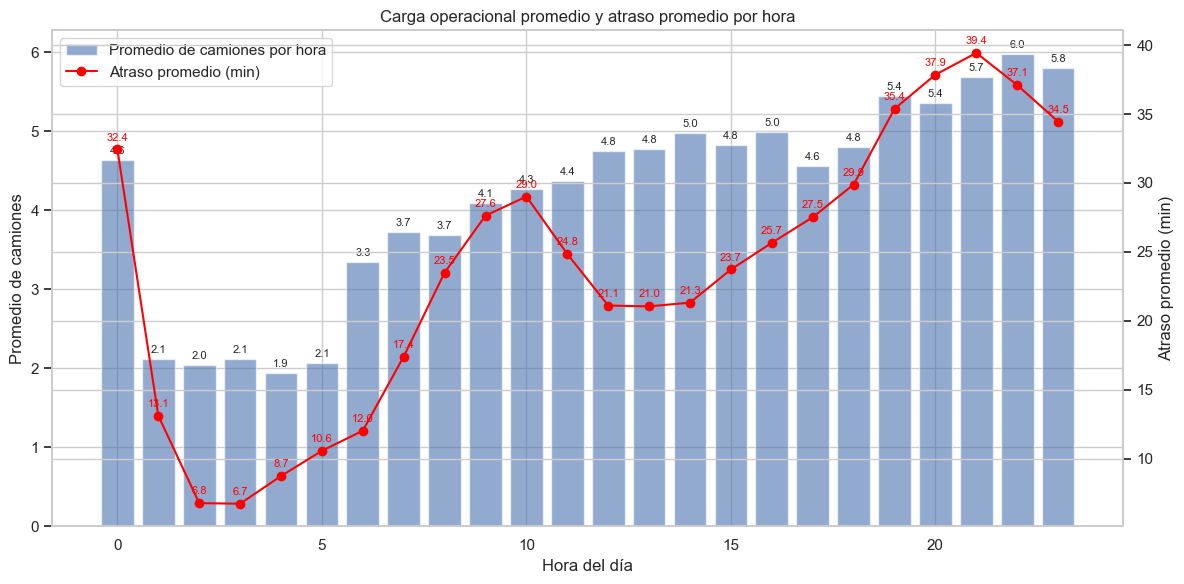

In [13]:
# Análisis de carga operacional y atraso promedio por hora
# Asegurar formato de fecha
dataset_eda["fecha"] = pd.to_datetime(dataset_eda["fecha"])

# Crear hora a partir de hora_programada_min
dataset_eda["hora"] = pd.to_datetime(dataset_eda["hora_ingreso_real"], format="%H:%M:%S").dt.hour

# Crear fecha sin hora
dataset_eda["fecha_dia"] = dataset_eda["fecha"].dt.date

# Camiones por hora por día
camiones_por_dia = (
    dataset_eda
    .groupby(["fecha_dia", "hora"])
    .size()
    .reset_index(name="camiones"))

# Promedio de camiones por hora
camiones_promedio = (
    camiones_por_dia
    .groupby("hora")["camiones"]
    .mean()
    .reset_index())


# Atraso promedio por hora
atraso_promedio = (
    dataset_eda
    .groupby("hora")["minutos_atraso"]
    .mean()
    .reset_index())

# Unir métricas
hora_stats = camiones_promedio.merge(
    atraso_promedio,
    on="hora"
)

# Gráfico
fig, ax1 = plt.subplots(figsize=(12,6))

#Promedio de camiones
bars = ax1.bar(
    hora_stats["hora"],
    hora_stats["camiones"],
    alpha=0.6,
    label="Promedio de camiones por hora")

ax1.set_xlabel("Hora del día")
ax1.set_ylabel("Promedio de camiones")

# Etiquetas en barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=8)

# atraso promedio
ax2 = ax1.twinx()

ax2.plot(
    hora_stats["hora"],
    hora_stats["minutos_atraso"],
    color="red",
    marker="o",
    label="Atraso promedio (min)")

ax2.set_ylabel("Atraso promedio (min)")

# Etiquetas en línea
for x, y in zip(hora_stats["hora"], hora_stats["minutos_atraso"]):
    ax2.text(
        x,
        y + 0.5,
        f"{y:.1f}",
        ha='center',
        va='bottom',
        fontsize=8,
        color="red")


ax2.set_ylabel("Atraso promedio (min)")

# Combinar leyendas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left")


plt.title("Carga operacional promedio y atraso promedio por hora")
plt.tight_layout()
plt.show()

## Distribución del atraso según hora programada

El gráfico muestra la distribución de los minutos de atraso según bloques horarios de dos horas.

Se observa que tanto la mediana como la dispersión de los atrasos tienden a aumentar hacia las últimas horas del día. Los bloques horarios de la tarde y noche presentan mayores niveles de atraso y mayor variabilidad, lo que sugiere posibles efectos de acumulación de operaciones y mayor presión operativa en esos periodos.

In [14]:
# Análisis de distribución de atrasos por bloque horario
dataset_eda["hora_programada_dt"] = pd.to_datetime(dataset_eda["hora_programada"], format="%H:%M:%S")
dataset_eda["hora"] = dataset_eda["hora_programada_dt"].dt.hour

bins = [0,2,4,6,8,10,12,14,16,18,20,22,24]
labels = ["00 a 02 hrs","02 a 04 hrs","04 a 06 hrs","06 a 08 hrs","08 a 10 hrs","10 a 12 hrs",
          "12 a 14 hrs","14 a 16 hrs","16 a 18 hrs","18 a 20 hrs","20 a 22 hrs","22 a 24 hrs"]

dataset_eda["bloque_hora"] = pd.cut(dataset_eda["hora"], bins=bins, labels=labels, right=False)
dataset_eda["bloque_hora"] = dataset_eda["bloque_hora"].astype(str)

fig = px.box(
    dataset_eda,
    x="bloque_hora",
    y="minutos_atraso",
    color="bloque_hora",
    points="outliers",
    title="Distribución de atrasos por bloque horario",
    category_orders={"bloque_hora": labels}
)

fig.update_layout(
    xaxis_title="Hora programada (bloques de 2 horas)",
    yaxis_title="Minutos de atraso",
    showlegend=False
)

fig.show()

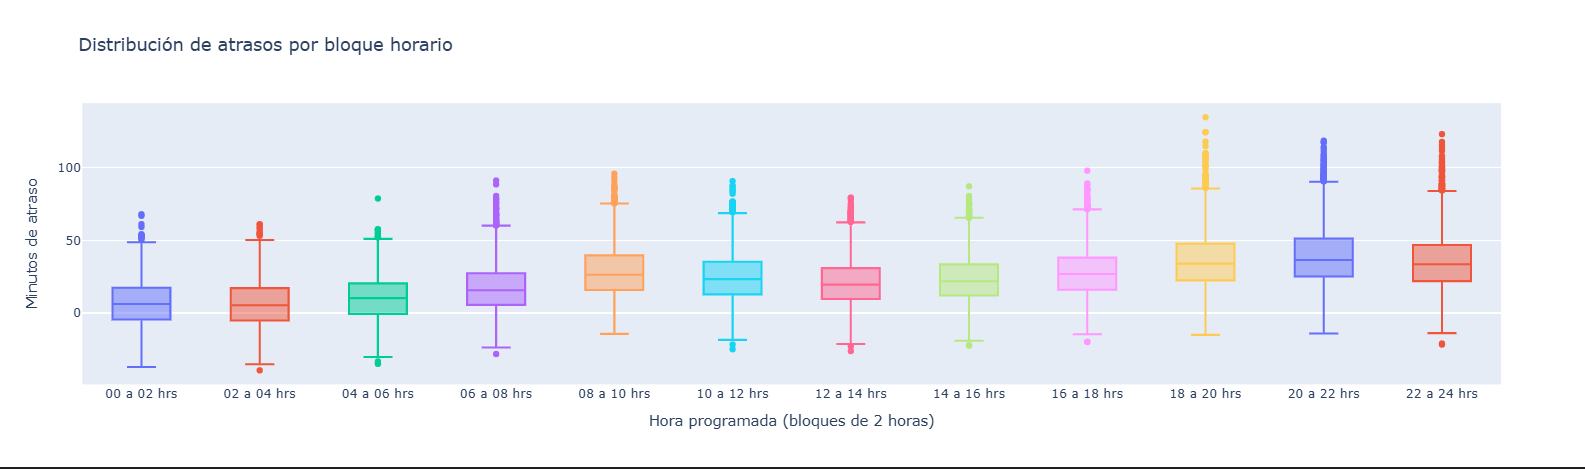

## Conclusiones del Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permitió identificar patrones relevantes en el comportamiento de los atrasos operacionales.

Principales hallazgos:

- Los atrasos tienden a aumentar a medida que avanza la jornada, con niveles más altos durante la tarde y noche.
- Existe una mayor concentración de operaciones durante las horas centrales del día, lo que puede generar acumulación operativa en horarios posteriores.
- Se observan diferencias en el comportamiento de los atrasos entre distintas empresas y contextos operacionales.

En conjunto, estos resultados sugieren que variables como **hora de operación, empresa, tipo de operación y tipo de carga** contienen información relevante para explicar la variabilidad de los atrasos y justifican su uso en el modelo predictivo.

## Feature Engineering y selección de variables

En esta etapa se definen las variables utilizadas para predecir los **minutos de atraso**.

La selección se basó en dos criterios:  
(1) lógica operacional del proceso logístico y  
(2) patrones identificados durante el análisis exploratorio de datos (EDA).

Se utilizan únicamente variables disponibles **antes de que ocurra la operación**, evitando problemas de *data leakage*. Por esta razón, no se consideran variables como la **hora de ingreso real** o la **hora de inicio de operación**, ya que ocurren después de la llegada del camión.

Las variables consideradas son:

- **empresa y patente:** capturan diferencias en el desempeño entre transportistas.
- **tipo_operacion y tipo_carga:** representan características operacionales que pueden influir en la complejidad de la operación.
- **hora:** corresponde a la **hora programada**, disponible antes de la llegada del camión.
- **dia_semana, mes y es_fin_semana:** permiten capturar patrones temporales.

Las variables categóricas se codifican mediante **One-Hot Encoding**, mientras que las variables numéricas se mantienen sin transformación adicional.

In [15]:
dt = dataset.copy()

dt["fecha"] = pd.to_datetime(dt["fecha"])

mapa_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

mapa_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

dt["dia_semana"] = dt["fecha"].dt.dayofweek.map(mapa_dias)
dt["mes"] = dt["fecha"].dt.month.map(mapa_meses)

dt["es_fin_semana"] = dt["dia_semana"].isin(["Sábado", "Domingo"]).astype(int)


dt["hora_programada_min"] = dt["hora_programada"].apply(hhmmss_to_minutes)

In [16]:
X = dt[
    [
        "empresa",
        "patente",
        "tipo_operacion",
        "tipo_carga",
        "hora_programada_min",
        "dia_semana",
        "mes",
        "es_fin_semana"
    ]
]

y = dt["minutos_atraso"]

In [17]:
categorical = [
    "empresa",
    "patente",
    "tipo_operacion",
    "tipo_carga",
    "dia_semana",
    "mes"
]

numeric = [
    "hora_programada_min",
    "es_fin_semana"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)
# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

In [18]:
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (28200, 8) (28200,)
Test shapes: (7050, 8) (7050,)


## Comparación de modelos:

Se evaluaron tres modelos de ML para predecir atrasos en operaciones logisticas:
1. Regresión Lineal
2. Random Forest
3. XGBoost

Cada modelo fue entrenado con el mismo conjunto de datos de entrenamiento y evaluado con el conjunto de datos de test

### Interpretación de las métricas:

Para evaluar el desempeño de los modelos se utilizaron las siguientes métricas:

- **MAE (Mean Absolute Error):** mide el error promedio de las predicciones en minutos.
- **R²:** indica qué proporción de la variabilidad de los datos logra explicar el modelo.

Un menor MAE indica mayor precisión en la predicción de atrasos.
Un mayor valor de R² indica que el modelo captura mejor los patrones presentes en los datos.

In [19]:
# Modelo de regresión lineal
lin = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())])

lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

print("Regresión Lineal")
print("MAE:", mean_absolute_error(y_test, pred_lin).__round__(2))
print("R2 :", r2_score(y_test, pred_lin).__round__(2))

Regresión Lineal
MAE: 8.89
R2 : 0.67


In [20]:
# Modelo de Random Forest
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=250,
        max_depth=14,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf).__round__(2))
print("R2 :", r2_score(y_test, pred_rf).__round__(2))

Random Forest
MAE: 9.31
R2 : 0.65


In [21]:

xgb = Pipeline([
    ("prep", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("XGBoost Regressor")
print("MAE:", mean_absolute_error(y_test, pred_xgb).__round__(2))
print("R2 :", r2_score(y_test, pred_xgb).__round__(2))

XGBoost Regressor
MAE: 7.84
R2 : 0.75


## Validación cruzada

Para evaluar la estabilidad de los modelos se aplicó **validación cruzada con 5 particiones** utilizando el error absoluto medio (MAE) como métrica.

Este procedimiento permite estimar el desempeño promedio del modelo en diferentes subconjuntos del dataset, y así no depender unicamente del split de entrenamiento y prueba.

Los resultados muestran que **XGBoost obtiene el menor error promedio**.

In [22]:
# Validación cruzada para XGBoost
scores_xgb = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("XGB CV MAE:", -scores_xgb.mean().round(2))


# Validación cruzada para Random Forest
scores_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)
print("Random Forest CV MAE:", -scores_rf.mean().__round__(2))

XGB CV MAE: 7.66
Random Forest CV MAE: 9.24


## Evaluación de atrasos críticos

Además de evaluar la precisión general del modelo, es importante analizar su capacidad para detectar **atrasos críticos** en la operación.

En este análisis se considera como atraso crítico cualquier operación con un atrasos mayor a **30 minutos**.

Para evaluar este comportamiento se utilizan dos métricas:

- **Recall:** capacidad del modelo para detectar correctamente los atrasos críticos.
- **Precision:** proporción de alertas generadas que realmente corresponden a atrasos críticos.

### Interpretación de resultados

Los resultados muestran que el modelo **XGBoost** obtiene nuevamente el mejor desempeño.

Este modelo presenta:

- El **mayor recall**, lo que indica una mayor capacidad para detectar atrasos críticos.
- La **mayor precisión**, lo que significa que las alertas generadas tienen una mayor probabilidad de corresponder a atrasos reales.

Esto es especialmente importante en un contexto operativo, donde si detectamos con anticipación posibles atrasos nos permitirá tomar acciones preventivas.

In [23]:
# Evaluamos desempeño en casos críticos (>30 min de atraso)
def evaluar_criticos(y_true, y_pred, threshold=30):
    y_true_bin = y_true > threshold
    y_pred_bin = y_pred > threshold


    return (
        recall_score(y_true_bin, y_pred_bin),
        precision_score(y_true_bin, y_pred_bin)
    )

rec_lin = evaluar_criticos(y_test, pred_lin)
rec_rf = evaluar_criticos(y_test, pred_rf)
rec_xgb = evaluar_criticos(y_test, pred_xgb)

comparacion = pd.DataFrame({
    "Modelo": ["Linear", "RandomForest", "XGBoost"],
    "Recall_>30": [rec_lin[0], rec_rf[0], rec_xgb[0]],
    "Precision_>30": [rec_lin[1], rec_rf[1], rec_xgb[1]]
})

comparacion = comparacion.sort_values("Recall_>30", ascending=False)
comparacion

,Modelo,Recall_>30,Precision_>30
2,XGBoost,0.792158,0.812456
0,Linear,0.785219,0.777396
1,RandomForest,0.733518,0.784125


### Resultados de los modelos:

Los resultados muestran que el modelo **XGBoost** obtuvo el mejor desempeño entre los modelos evaluados, por lo que fue  seleccionado para realizar la predicción de los minutos de atraso.

Su elección se justifica ya que logró el menor error promedio en la predicción de atrasos y el mayor valor de R², lo que indica una mejor capacidad para capturar los patrones de relaciones no lineales presentes en las variables de los datos operacionales.

## Interpretación operacional:

El modelo **xgboost** logra predecir atrasos con un error promedio cercano a los **8 minutos**.

Considerando la variabilidad propia de las operaciones logísticas (tráfico, congestión operativa, tiempos de carga), este nivel de precisión puede ser útil para anticipar posibles atrasos y apoyar la toma de decisiones operacionales.

In [24]:
resultados = pd.DataFrame({
    "modelo": ["Linear", "RandomForest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, pred_lin).__round__(2),
        mean_absolute_error(y_test, pred_rf).__round__(2),
        mean_absolute_error(y_test, pred_xgb).__round__(2),
    ],
    "R2": [
        r2_score(y_test, pred_lin).__round__(2),
        r2_score(y_test, pred_rf).__round__(2),
        r2_score(y_test, pred_xgb).__round__(2),
    ]
}).sort_values("MAE")

resultados

,modelo,MAE,R2
2,XGBoost,7.84,0.75
0,Linear,8.89,0.67
1,RandomForest,9.31,0.65


In [25]:
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


In [26]:
best_model_name = "xgboost"
pred_best = pred_xgb

## Interpretabilidad del modelo (SHAP)

El gráfico SHAP muestra el impacto de cada variable en las predicciones del modelo.

La **empresa** y la **hora de inicio de operación** aparecen como los factores más influyentes, lo que indica que tanto el operador logístico como el momento efectivo en que comienzan las operaciones influyen significativamente en los minutos de atraso.

Variables como **tipo de carga, mes y día de la semana** presentan un impacto moderado, sugiriendo que ciertas condiciones operativas y temporales también contribuyen a explicar la variabilidad de los atrasos.

En cambio, el **tipo de operación** muestra una influencia menor en comparación con el resto de las variables.

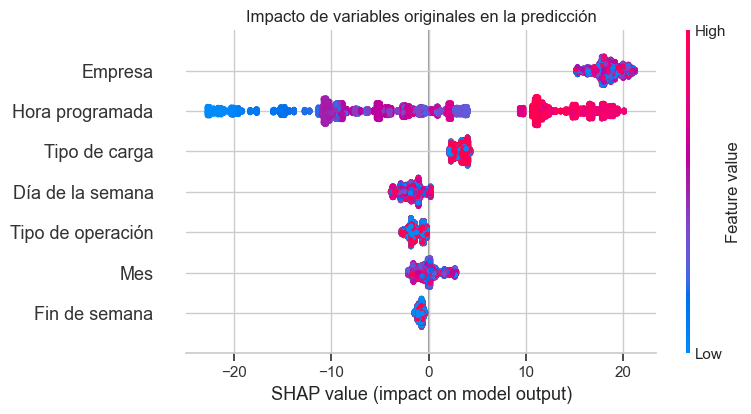

,variable,mean_abs_shap
0,Empresa,18.445711
1,Hora programada,10.499877
2,Tipo de carga,3.368071
3,Día de la semana,1.779346
4,Tipo de operación,1.369094
5,Mes,0.886044
6,Fin de semana,0.844054


In [27]:

# Transformación con el pipeline
X_test_transf = xgb.named_steps["prep"].transform(X_test)
xgb_model = xgb.named_steps["model"]
feature_names = xgb.named_steps["prep"].get_feature_names_out()

X_test_dense = X_test_transf if isinstance(X_test_transf, np.ndarray) else X_test_transf.toarray()
X_test_transf_df = pd.DataFrame(X_test_dense, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transf_df)


grupos = {
    "Empresa": [c for c in feature_names if c.startswith("cat__empresa")],
    "Tipo de operación": [c for c in feature_names if c.startswith("cat__tipo_operacion")],
    "Tipo de carga": [c for c in feature_names if c.startswith("cat__tipo_carga")],
    "Hora programada": ["num__hora_programada_min"],
    "Día de la semana": [c for c in feature_names if c.startswith("cat__dia_semana")],
    "Mes": [c for c in feature_names if c.startswith("cat__mes")],
    "Fin de semana": ["num__es_fin_semana"],
}

# SHAP agrupado
shap_grouped = pd.DataFrame(index=X_test.index)

for nombre, cols in grupos.items():
    cols_validas = [c for c in cols if c in X_test_transf_df.columns]
    if len(cols_validas) > 0:
        idx = [X_test_transf_df.columns.get_loc(c) for c in cols_validas]
        shap_grouped[nombre] = shap_values[:, idx].sum(axis=1)

# Valores para colorear en el beeswarm
# numéricas: valor real
# categóricas: códigos solo para color
features_grouped = pd.DataFrame(index=X_test.index)

features_grouped["Hora programada"] = X_test["hora_programada_min"].values
features_grouped["Fin de semana"] = X_test["es_fin_semana"].values

features_grouped["Empresa"] = pd.Categorical(X_test["empresa"]).codes
features_grouped["Tipo de operación"] = pd.Categorical(X_test["tipo_operacion"]).codes
features_grouped["Tipo de carga"] = pd.Categorical(X_test["tipo_carga"]).codes
features_grouped["Día de la semana"] = pd.Categorical(X_test["dia_semana"]).codes
features_grouped["Mes"] = pd.Categorical(X_test["mes"]).codes

#ordenar según importancia promedio
orden = shap_grouped.abs().mean().sort_values(ascending=False).index
shap_grouped = shap_grouped[orden]
features_grouped = features_grouped[orden]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_grouped.values,
    features_grouped,
    feature_names=shap_grouped.columns.tolist(),
    show=False
)

plt.title("Impacto de variables originales en la predicción")
plt.tight_layout()
plt.savefig("outputs/figures/shap_grouped_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla de importancia SHAP
shap_importance_dt = (
    shap_grouped.abs()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

shap_importance_dt.columns = ["variable", "mean_abs_shap"]
shap_importance_dt

## Comparación entre valores reales y predichos

El gráfico muestra la relación entre los valores reales de atraso y los valores predichos por el modelo XGBoost.

Idealmente, las observaciones deberían alinearse cerca de una línea diagonal, lo que indicaría que las predicciones del modelo coinciden con los valores reales.

En este caso se observa una clara relación positiva entre ambos valores, lo que sugiere que el modelo logra capturar correctamente la tendencia general de los atrasos en la operación.

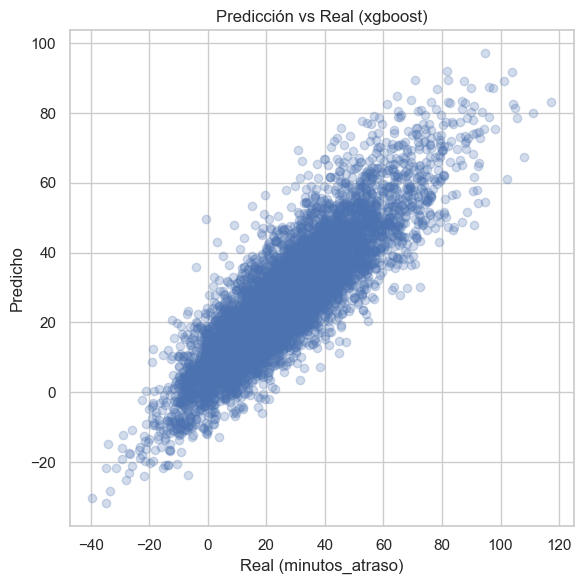

In [28]:
ensure_dir("outputs/figures")

# Pred vs Real
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.25)
plt.title(f"Predicción vs Real ({best_model_name})")
plt.xlabel("Real (minutos_atraso)")
plt.ylabel("Predicho")
plt.tight_layout()
plt.savefig(f"outputs/figures/pred_vs_real_{best_model_name}.png", dpi=150)
plt.show()

## Análisis de residuos

El gráfico muestra la distribución de los residuos, que se define como la diferencia entre el valor real y el valor predicho por el modelo.

Una distribución centrada cerca de cero indica que el modelo no presenta un sesgo sistemático en sus predicciones.

En este caso, los residuos se distribuyen principalmente alrededor de cero, lo que sugiere que el modelo mantiene un comportamiento relativamente equilibrado entre sobreestimación y subestimación.

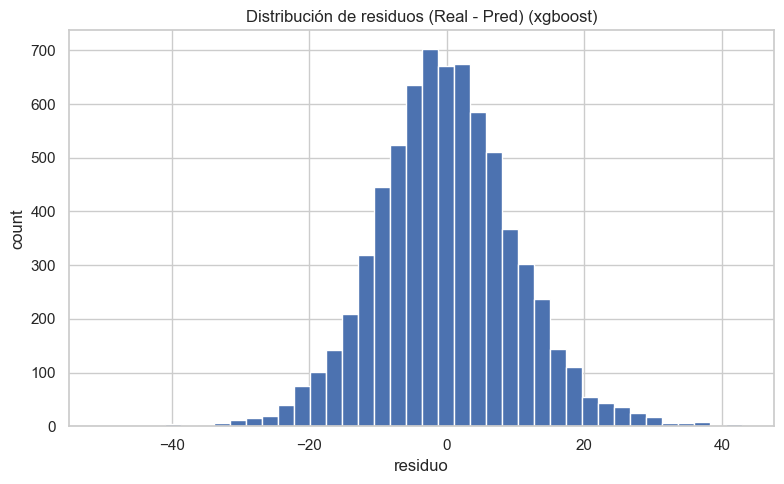

In [29]:
# Residuos
resid = y_test - pred_best
plt.figure(figsize=(8,5))
plt.hist(resid, bins=40)
plt.title(f"Distribución de residuos (Real - Pred) ({best_model_name})")
plt.xlabel("residuo")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(f"outputs/figures/residuos_{best_model_name}.png", dpi=150)
plt.show()

## Análisis del umbral de alerta

En el análisis anterior se consideró como atraso crítico cualquier operación con más de **30 minutos de atraso**.

Sin embargo, desde un punto de vista operativo puede ser útil ajustar el **umbral de alerta del modelo** para mejorar su capacidad de detección.

Por esta razón se realiza un barrido de distintos valores de umbral de predicción para analizar cómo cambian las métricas de **recall** y **precision**.

## Interpretación del barrido de umbral

La tabla muestra cómo varía el desempeño del modelo cuando se modifica el umbral utilizado para generar alertas.

Se observa el comportamiento esperado:

- Umbrales **más bajos** generan más alertas y aumentan el **recall**.
- Umbrales **más altos** reducen el número de alertas pero aumentan la **precision**.

Esto refleja un trade-off entre detectar más casos críticos o reducir la cantidad de falsas alarmas.

In [30]:
#Umbral vs Recall/Precision
def threshold_report(y_true, y_pred, pred_threshold, real_threshold=30):
    y_true_bin = y_true > real_threshold
    y_pred_bin = y_pred > pred_threshold
    return {
        "Umbral_pred": pred_threshold,
        "Alertas_generadas": int(y_pred_bin.sum()),
        "Criticos_reales": int(y_true_bin.sum()),
        "Recall": recall_score(y_true_bin, y_pred_bin),
        "Precision": precision_score(y_true_bin, y_pred_bin),
    }


thresholds = np.arange(15, 45, 2)
grid = pd.DataFrame([threshold_report(y_test, pred_best, t) for t in thresholds])
grid

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,15,5350,2882,0.992019,0.534393
1,17,5048,2882,0.988203,0.564184
2,19,4721,2882,0.977793,0.596907
3,21,4343,2882,0.963567,0.639420
4,23,3963,2882,0.939278,0.683068
5,25,3638,2882,0.909785,0.720726
6,27,3286,2882,0.865371,0.758977
7,29,2976,2882,0.820611,0.794691
8,31,2642,2882,0.762665,0.831945
9,33,2370,2882,0.709577,0.862869


### Selección de un umbral operativo

El objetivo de este análisis es encontrar un umbral que permita detectar una mayor proporción de atrasos críticos sin generar un exceso de alertas.

Por ejemplo, al utilizar un umbral cercano a **25 minutos**, el modelo logra mantener un nivel de precisión razonable mientras mejora la capacidad de detección de atrasos críticos.

## Selección del umbral óptimo

Para definir un umbral operativo se evaluaron distintos valores de alerta sobre la predicción del modelo.

Se utilizó el **F1 Score**, que combina recall y precision, como criterio para encontrar un equilibrio entre:

- Detectar la mayor cantidad posible de atrasos críticos
- Evitar generar un exceso de falsas alertas

El análisis identificó **27 minutos** como el umbral que maximiza el balance entre ambas métricas.

In [31]:
# Escoger el que maximiza F1 (balance)
grid["F1"] = 2 * (grid["Precision"] * grid["Recall"]) / (grid["Precision"] + grid["Recall"])
best_threshold = int(grid.sort_values("F1", ascending=False).iloc[0]["Umbral_pred"])


In [32]:
cmp = pd.DataFrame([
    threshold_report(y_test, pred_best, 30),
    threshold_report(y_test, pred_best, best_threshold)
])
cmp

,Umbral_pred,Alertas_generadas,Criticos_reales,Recall,Precision
0,30,2810,2882,0.792158,0.812456
1,27,3286,2882,0.865371,0.758977


### Trade-off entre Recall y Precision

El gráfico muestra cómo cambian las métricas al modificar el umbral de alerta.

Se observa que:

- Umbrales **más bajos** aumentan el recall (se detectan más atrasos críticos).
- Umbrales **más altos** aumentan la precision (menos falsas alertas).

El umbral seleccionado representa un punto de equilibrio donde el modelo logra detectar una proporción importante de atrasos críticos manteniendo un nivel razonable de precisión.

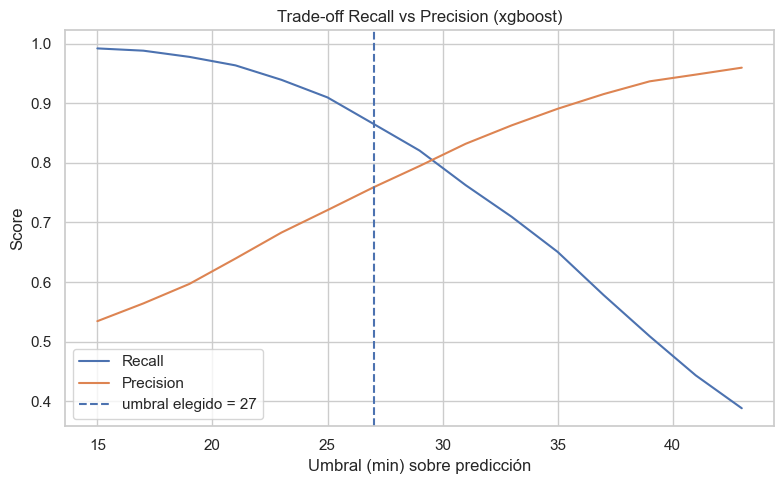

In [33]:
ensure_dir("outputs/figures")

plt.figure(figsize=(8,5))
plt.plot(grid["Umbral_pred"], grid["Recall"], label="Recall")
plt.plot(grid["Umbral_pred"], grid["Precision"], label="Precision")
plt.axvline(best_threshold, linestyle="--", label=f"umbral elegido = {best_threshold}")
plt.xlabel("Umbral (min) sobre predicción")
plt.ylabel("Score")
plt.title(f"Trade-off Recall vs Precision ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.savefig(f"outputs/figures/threshold_tradeoff_{best_model_name}.png", dpi=150)
plt.show()

## Impacto operacional

Comparando ambos escenarios:

**Umbral tradicional (30 min)**  
- Recall: ~ 0.79  
- Precision: ~0.81
- Alertas generadas: 2.804 casos


**Umbral optimizado (27 min)**  
- Recall: ~0.87 
- Precision: ~0.76  
- Alertas generadas: 3.287 casos

El cambio de umbral aumenta las alertas generadas en **483 casos**, permitiendo detectar una mayor proporción de atrasos críticos.

Esto permite detectar una mayor proporción de atrasos reales, lo cual es preferible en un contexto operacional donde si omitimos un atraso nos puede generar un mayor impacto en la planificación logistica.

In [34]:
def minutes_to_hhmmss(m):
    m = int(round(m)) % 1440
    h = m // 60
    mm = m % 60
    return f"{h:02d}:{mm:02d}:00"

## Priorización de operaciones con mayor riesgo de atraso

El modelo entrenado permite estimar los **minutos de atraso esperados** para cada operación logística. A partir de esta predicción se define una **clasificación de riesgo**, que facilita priorizar las operaciones que requieren mayor atención operacional.

### Clasificación de riesgo

Se define un **umbral operativo de 27 minutos de atraso**. En función de este valor, las predicciones del modelo se agrupan en cuatro niveles de riesgo:

| Nivel de riesgo | Condición |
|---|---|
| **Crítico** | atraso ≥ 27 minutos |
| **Alto** | atraso entre 19 y 26 minutos |
| **Medio** | atraso entre 11 y 18 minutos |
| **Bajo** | atraso < 11 minutos |

### Priorización de operaciones

Las operaciones se ordenan según:

1. **Nivel de riesgo** (Crítico -> Alto -> Medio -> Bajo)  
2. **Minutos de atraso predichos**

De esta forma, es posible identificar rápidamente **las operaciones con mayor probabilidad de generar congestión**, permitiendo priorizar su monitoreo o gestión operativa

### Top operaciones con mayor riesgo de atraso

In [35]:
ensure_dir("outputs/tables")

prior = X_test.copy()

prior["fecha"] = dataset.loc[X_test.index, "fecha"]
prior["minutos_reales"] = y_test.values
prior["minutos_predichos"] = pred_best.round().astype(int)

prior["alerta_critica"] = prior["minutos_predichos"] >= best_threshold


# Nivel de riesgo
def clasificar_riesgo(x, threshold):

    if x >= threshold:
        return "Crítico"

    elif x >= threshold * 0.7:
        return "Alto"

    elif x >= threshold * 0.4:
        return "Medio"

    else:
        return "Bajo"


prior["nivel_riesgo"] = prior["minutos_predichos"].apply(
    lambda x: clasificar_riesgo(x, best_threshold)
)


prior["hora_programada"] = prior["hora_programada_min"].apply(minutes_to_hhmmss)

prior["fecha"] = pd.to_datetime(prior["fecha"]).dt.strftime("%d-%m-%Y")


orden_riesgo = {"Crítico":4,"Alto":3,"Medio":2,"Bajo":1}

prior["orden_riesgo"] = prior["nivel_riesgo"].map(orden_riesgo)


prior = prior.sort_values(
    ["orden_riesgo","minutos_predichos"],
    ascending=[False,False]
)


cols_deseadas = [
    "fecha",
    "empresa",
    "patente",
    "tipo_operacion",
    "tipo_carga",
    "hora_programada",
    "minutos_predichos",
    "nivel_riesgo"
]

cols_final = [c for c in cols_deseadas if c in prior.columns]

prior_final = prior[cols_final].head(20)

prior_final

,fecha,empresa,patente,tipo_operacion,tipo_carga,hora_programada,minutos_predichos,nivel_riesgo
5022,11-12-2025,VentiscaLine Transport,TRK-059,Recepcion,Carga Suelta,19:54:00,97,Crítico
28858,28-04-2025,CumbreKargo 24,TRK-010,Recepcion,Carga Suelta,23:46:00,92,Crítico
20146,01-05-2025,CumbreKargo 24,TRK-068,Despacho,Carga Suelta,23:07:00,92,Crítico
34963,28-06-2025,CumbreKargo 24,TRK-037,Recepcion,Carga Suelta,23:21:00,90,Crítico
20174,02-05-2025,CumbreKargo 24,TRK-043,Despacho,Carga Suelta,23:01:00,89,Crítico
16225,01-09-2025,CumbreKargo 24,TRK-004,Despacho,Carga Suelta,20:32:00,89,Crítico
10658,17-12-2025,CumbreKargo 24,TRK-078,Recepcion,Carga Suelta,18:21:00,89,Crítico
12659,01-08-2025,CumbreKargo 24,TRK-068,Despacho,Pallet,20:26:00,87,Crítico
20035,29-08-2025,VentiscaLine Transport,TRK-047,Despacho,Carga Suelta,20:37:00,87,Crítico
22461,27-07-2025,CumbreKargo 24,TRK-022,Recepcion,Carga Suelta,22:20:00,87,Crítico


## Conclusiones

En este proyecto se desarrolló un modelo de *Machine Learning* para predecir atrasos en operaciones logísticas y generar alertas tempranas de posibles casos críticos.

El análisis exploratorio de datos permitió identificar patrones relevantes en el comportamiento de los atrasos. En particular, los gráficos por bloque horario y carga operacional muestran que los atrasos tienden a incrementarse durante las últimas horas del día, especialmente cuando aumenta la concentración de operaciones programadas. Esto sugiere que parte de los atrasos podría estar asociada a fenómenos de congestión operativa acumulada a lo largo de la jornada.

Tras evaluar distintos algoritmos de predicción, **XGBoost fue seleccionado como el modelo con mejor desempeño predictivo**, logrando estimar los minutos de atraso con un **error promedio cercano a 8 minutos**.

Posteriormente se optimizó el **umbral de alerta**, ajustándolo desde 30 a aproximadamente **27 minutos**, lo que permite detectar una mayor proporción de atrasos críticos y mejorar la capacidad del sistema para anticipar situaciones operacionales complejas.

Finalmente, el modelo permite generar una **priorización de operaciones con mayor riesgo de atraso**, lo que podría utilizarse como herramienta de monitoreo para apoyar la toma de decisiones en la gestión logística, identificando las operaciones que requieran atención prioritaria.